# 05 Revenue And Customer Value Proxy

## Goal

Analyze revenue, AOV, ARPU, cohort revenue, customer concentration, and observed customer value proxy.

## Setup

Connect to the local DuckDB database created by the transformation pipeline.

In [2]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import duckdb
import pandas as pd
import matplotlib.pyplot as plt

from product_growth_analytics.notebook_utils import connect, query_df, read_sql

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", "{:.4f}".format)
con = connect()

## Concept

Revenue analysis should use purchase events only. Customer lifetime value is only a proxy here because we have two months and no margin data.

In [3]:
daily_revenue = query_df(con, read_sql("analysis/revenue.sql"))
daily_revenue.head()

,purchase_date,revenue,purchase_events,purchasing_users,aov_per_purchase_event,revenue_per_purchasing_user
0,2019-10-01,6275964.0100,19307,14064,325.0616,446.2432
1,2019-10-02,6213628.5300,19469,13894,319.1550,447.2167
2,2019-10-03,6233782.9800,19255,13722,323.7488,454.2911
3,2019-10-04,8623684.4700,27041,19214,318.9114,448.8230
4,2019-10-05,7341596.9100,23494,16734,312.4882,438.7234


In [4]:
summary = query_df(con, """
SELECT
    SUM(revenue) AS revenue,
    COUNT(*) AS purchase_events,
    COUNT(DISTINCT user_id) AS purchasing_users,
    SUM(revenue) * 1.0 / COUNT(*) AS aov_per_purchase_event,
    SUM(revenue) * 1.0 / COUNT(DISTINCT user_id) AS revenue_per_buyer
FROM analytics.fact_purchases
""")
summary

,revenue,purchase_events,purchasing_users,aov_per_purchase_event,revenue_per_buyer
0,505152392.7700,1659788,697470,304.3475,724.2640


In [5]:
customer_value = query_df(con, """
SELECT
    user_id,
    SUM(revenue) AS observed_customer_value,
    COUNT(*) AS purchase_events,
    COUNT(DISTINCT purchase_date) AS purchase_days
FROM analytics.fact_purchases
GROUP BY 1
ORDER BY observed_customer_value DESC
""")
customer_value.head()

,user_id,observed_customer_value,purchase_events,purchase_days
0,512386086,344153.2900,590,60
1,515384420,303144.2400,182,46
2,513117637,266331.2400,212,37
3,519267944,265569.5200,183,29
4,518514099,203986.0700,202,10


In [6]:
pareto = customer_value.assign(
    revenue_rank=lambda df: df["observed_customer_value"].rank(method="first", ascending=False),
    cumulative_revenue=lambda df: df["observed_customer_value"].cumsum(),
)
pareto["cumulative_revenue_share"] = pareto["cumulative_revenue"] / pareto["observed_customer_value"].sum()
pareto.head(10)

,user_id,observed_customer_value,purchase_events,purchase_days,revenue_rank,cumulative_revenue,cumulative_revenue_share
0,512386086,344153.2900,590,60,1.0000,344153.2900,0.0007
1,515384420,303144.2400,182,46,2.0000,647297.5300,0.0013
2,513117637,266331.2400,212,37,3.0000,913628.7700,0.0018
3,519267944,265569.5200,183,29,4.0000,1179198.2900,0.0023
4,518514099,203986.0700,202,10,5.0000,1383184.3600,0.0027
5,530834332,188820.8700,176,29,6.0000,1572005.2300,0.0031
6,549109608,184394.5200,376,46,7.0000,1756399.7500,0.0035
7,534545940,183309.0300,178,48,8.0000,1939708.7800,0.0038
8,532499743,180755.4000,152,22,9.0000,2120464.1800,0.0042
9,515715331,175747.2600,125,35,10.0000,2296211.4400,0.0045


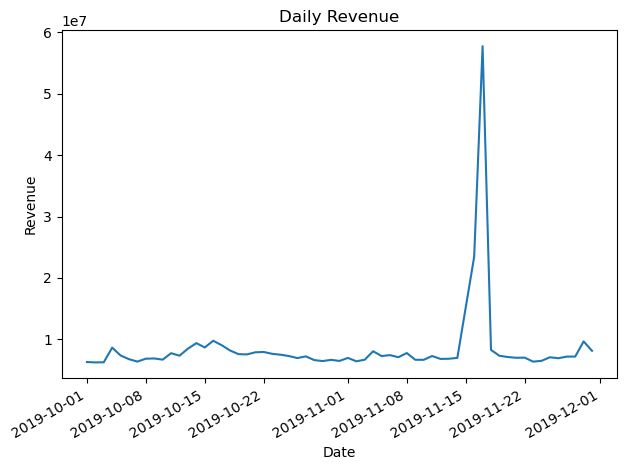

In [7]:
ax = daily_revenue.plot(x="purchase_date", y="revenue", title="Daily Revenue", legend=False)
ax.set_xlabel("Date")
ax.set_ylabel("Revenue")
plt.tight_layout()

## Takeaways

- Total observed purchase revenue is **505.15M** from **1,659,788 purchase events** and **697,470 purchasing users**.
- Average order value at the purchase-event level is **304.35**, while revenue per purchasing user is **724.26**. This means buyer value is driven by both order size and repeat purchase behavior.
- November generated more revenue than October: **275.19M** versus **229.96M**, with more purchase events and more buyers. However, November includes the known mid-month anomaly, so revenue growth should be interpreted with annotation.
- The top observed customer generated **344,153.29** in revenue across **590 purchase events** and **60 purchase days**. This is a customer value proxy, not true LTV, because we only have two months of data and no margin/cost data.
- Revenue is meaningfully concentrated: about **10,116 buyers** generate 25% of revenue, **50,507 buyers** generate 50%, and **196,107 buyers** generate 80% out of **697,470 total buyers**.
- The maximum revenue day is **2019-11-17**, which sits inside the November 15-17 anomaly window. This should be separated from normal trend interpretation in dashboards and recommendations.

Overall, revenue is large and buyer value is concentrated enough to justify lifecycle segmentation. The next product question is which behaviors distinguish high-value and repeat buyers from one-time or low-value buyers.